<a href="https://colab.research.google.com/github/Dark-Knight17/keystroke-dynamics-thesis/blob/main/keystroke_cnn_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

from google.colab import drive
drive.mount('/content/drive')

--- PART 1: DEFINING THE NEURAL NETWORK ---
--- PART 2: LOADING & PREPROCESSING DATA ---
Total Unique Participants: 50
Total Sessions Processed: 413

--- PART 3: THE LEAVE-ONE-OUT PROTOCOL ---
Target Genuine User ID: 07c7a634-bc94-4a69-8d27-9e1bad1328fa
Genuine Sessions (Class 1): 12
Impostor Sessions (Class 0): 401

--- PART 4: COMPILING & TRAINING ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9636 - auc: 0.4897 - loss: 0.1994 - val_accuracy: 0.9759 - val_auc: 0.8611 - val_loss: 0.1837
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9697 - auc: 0.4684 - loss: 0.1550 - val_accuracy: 0.9759 - val_auc: 0.8519 - val_loss: 0.1415
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9697 - auc: 0.6283 - loss: 0.1375 - val_accuracy: 0.9759 - val_auc: 0.7901 - val_loss: 0.1333
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9697 - auc: 0.5848 - loss: 0.1412 - val_accuracy: 0.9759 - val_auc: 0.7531 - val_loss: 0.1319
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9697 - auc: 0.5556 - loss: 0.1452 - val_accuracy: 0.9759 - val_auc: 0.7994 - val_loss: 0.1360
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9697 - auc: 0.6241 - loss: 0.1359 - val_accuracy: 0.9759 - val_auc: 0.5772 - val_loss: 0.1698
Epoch 7/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms

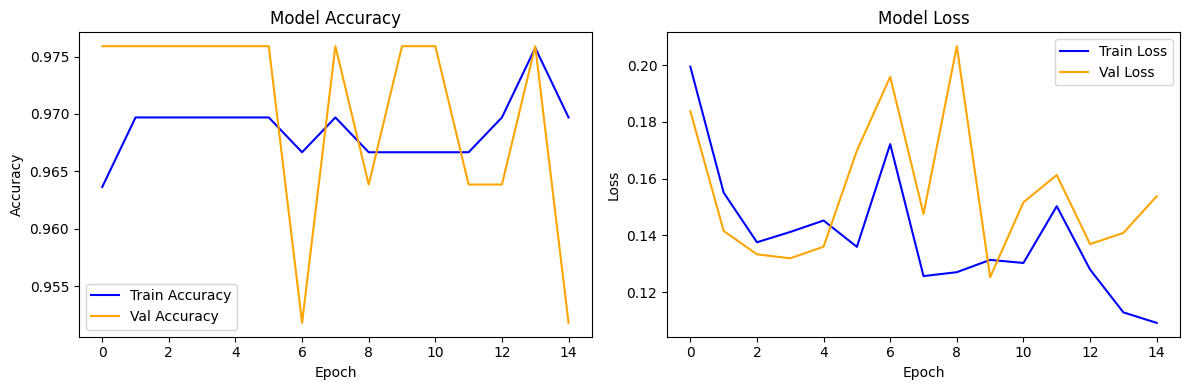

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Masking, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization

print("--- PART 1: DEFINING THE NEURAL NETWORK ---")
def build_cnn_lstm_model(max_timesteps, num_features):
    model = Sequential([
        Input(shape=(max_timesteps, num_features)),
        Masking(mask_value=-999.0),

        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        LSTM(units=64, return_sequences=False),
        Dropout(0.3),

        Dense(units=32, activation='relu'),
        Dropout(0.2),

        Dense(units=1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

print("--- PART 2: LOADING & PREPROCESSING DATA ---")
# Ensure this path matches your Google Drive setup
df = pd.read_csv('/content/drive/MyDrive/Keystroke_data/events_with_abs_timestamps_26P_19_may.csv')
df = df.sort_values(by=['session_id', 'timestamp'])

encoder = LabelEncoder()
df['physical_code_encoded'] = encoder.fit_transform(df['physical_code'].astype(str))

sequence_data = []
participant_labels = []

for session_id, session_group in df.groupby('session_id'):
    kd_group = session_group[session_group['event_type'] == 'keydown'].copy()
    if len(kd_group) == 0:
        continue

    kd_group['flight_time'] = kd_group['timestamp'].diff().fillna(0)
    features = kd_group[['physical_code_encoded', 'flight_time', 'text_length']].values

    sequence_data.append(features)
    participant_labels.append(session_group['participant_id'].iloc[0])

MAX_TIMESTEPS = 300
NUM_FEATURES = 3

X_data = pad_sequences(
    sequence_data,
    maxlen=MAX_TIMESTEPS,
    dtype='float32',
    padding='post',
    truncating='post',
    value=-999.0
)

participant_labels = np.array(participant_labels)
unique_users = np.unique(participant_labels)

print(f"Total Unique Participants: {len(unique_users)}")
print(f"Total Sessions Processed: {X_data.shape[0]}")

print("\n--- PART 3: THE LEAVE-ONE-OUT PROTOCOL ---")
target_user = unique_users[0]
print(f"Target Genuine User ID: {target_user}")

y_binary = np.where(participant_labels == target_user, 1, 0)
print(f"Genuine Sessions (Class 1): {np.sum(y_binary == 1)}")
print(f"Impostor Sessions (Class 0): {np.sum(y_binary == 0)}")

X_train, X_val, y_train, y_val = train_test_split(
    X_data, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print("\n--- PART 4: COMPILING & TRAINING ---")
# We instantiate the model dynamically based on your data's exact shape
model = build_cnn_lstm_model(X_data.shape[1], X_data.shape[2])

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=8,
    verbose=1
)

print("\n--- PART 5: EVALUATION PLOTS ---")
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()